# 1. Для изображения sar_3.jpg найти наиболее протяженный участок
# (выделить линии при помощи преобразования Хафа)
# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


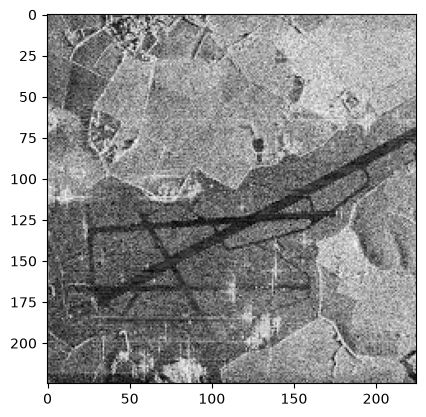

In [16]:
img = cv2.imread('sar_3.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray')
plt.show()

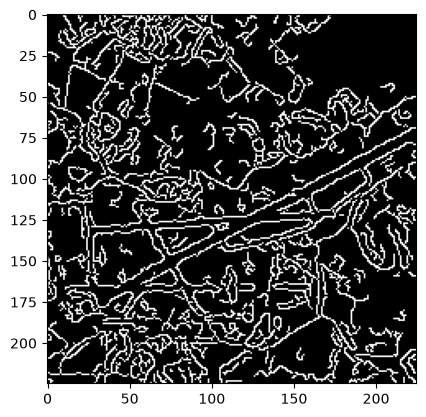

In [17]:
image_gauss = cv2.GaussianBlur(img_gray, (5, 5), 0)
image_median = cv2.medianBlur(image_gauss, 3)


canny = cv2.Canny(image_median, 50, 100)
plt.imshow(canny, cmap='gray')
plt.show()

In [18]:
# HoughLinesP, bc HoughLines gives only full lines, while HoughLinesP gives line segments

lines = cv2.HoughLinesP(canny, 1, np.pi / 180, threshold=50, minLineLength=20, maxLineGap=10)

In [19]:
print(lines.shape)

(116, 4)


In [20]:
lengths = []
for line in lines:
    x1, y1, x2, y2 = line
    length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    lengths.append(length)

In [21]:
image_lines = img_gray.copy()

for line in lines:
    lx1, ly1, lx2, ly2 = line
    cv2.line(image_lines, (lx1, ly1), (lx2, ly2), (0, 255, 0), 1)

#cv2.line(image_lines, (x1, y1), (x2, y2), (0, 0, 255), 3)
#plt.imshow(cv2.cvtColor(image_lines, cv2.COLOR_BGR2RGB))
#plt.show()

longest segment: (45,163) to (223,69), length=201.2958


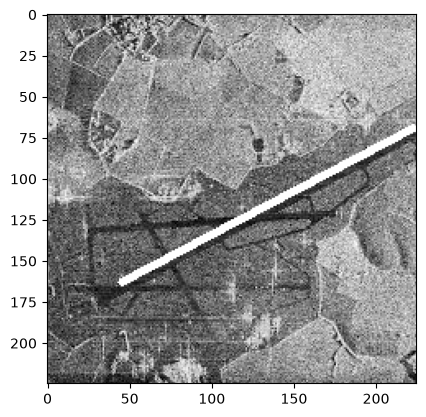

In [22]:
lengths = np.array(lengths)
longest_idx = np.argmax(lengths)
x1, y1, x2, y2 = lines[longest_idx]
print(f'longest segment: ({x1},{y1}) to ({x2},{y2}), length={lengths[longest_idx]:.4f}')

img_longest = img_gray.copy()

cv2.line(img_longest, (x1, y1), (x2, y2), (255, 255, 255), 3)
plt.imshow(img_longest, cmap='gray')
plt.show()

In [23]:

# img_5 = img_gray.copy()
# idxs = np.argsort(lengths)[-5:][::-1]
# for i in idxs:
#     x1, y1, x2, y2 = lines[i]
#     print(f'({x1},{y1}) to ({x2},{y2}), length={lengths[i]:.2f}')
#     cv2.line(img_5, (x1, y1), (x2, y2), (255, 255, 255), 2)
# plt.imshow(img_5, cmap='gray')
# plt.show()


In [24]:
#point binarization
T = 80
bin_img = img_gray.copy()
bin_img[img_gray < T] = 0
bin_img[img_gray >= T] = 255

In [25]:
_, otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

In [26]:
adaptive = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 71, 15)

Text(0.5, 1.0, 'adaptive')

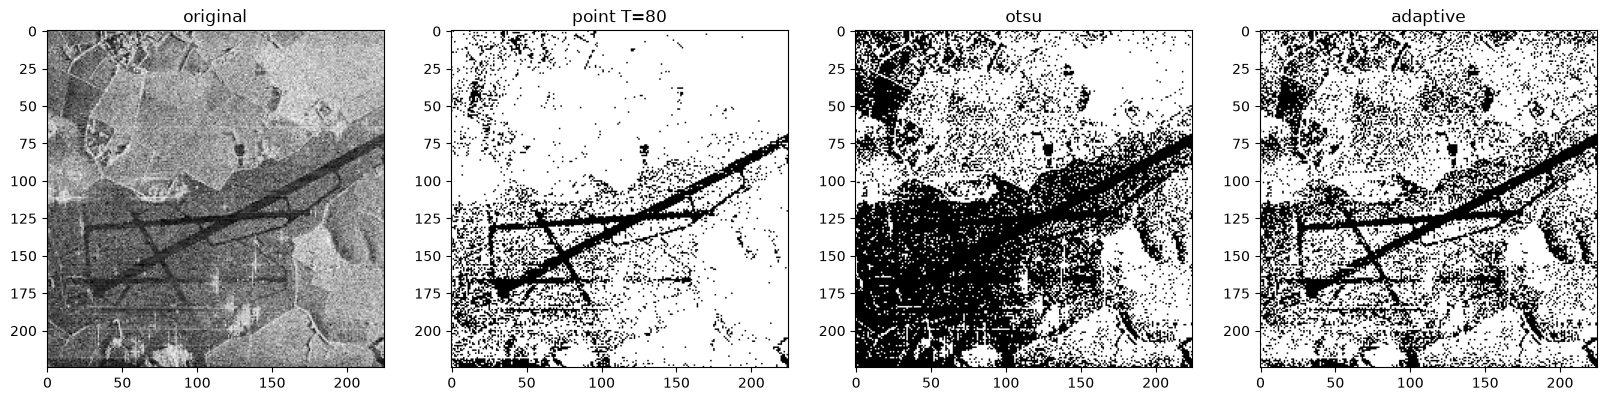

In [27]:
_, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(img_gray, cmap='gray')
axs[0].set_title('original')
axs[1].imshow(bin_img, cmap='gray')
axs[1].set_title(f'point T={T}')
axs[2].imshow(otsu, cmap='gray')
axs[2].set_title('otsu')
axs[3].imshow(adaptive, cmap='gray')
axs[3].set_title('adaptive')

# point binarization gives the best result for this img